# Sweden school assessment results — two vintages, merge & investigate

**Source.** Two independently-shaped Skolverket vintages, both school-unit
(`skolenhetskod`) grain:

* **`siris`** — the pre-2020 SIRIS archive, preserved (not rehosted) on
  Skolverket's own S3 bucket via the `jplusplus/skolstatistik` project.
  Läsår 1997/98–2018/19 (år 1998–2019). Fetched with
  `python -m src.cli sweden data assessments fetch-siris --dataset-key
  {slutbetyg_arskurs9,salsa}`, preprocessed with `preprocess-siris`.
* **`kvalitetssystem`** — Skolverket's *live* PxWeb "national quality
  system" API, läsår 2022/23–2025/26 only (a real ~2-year legal gap sits
  between the two: a Dec-2019 court ruling forced a school-level statistics
  blackout from Sept 2020 until a July 2021 law restored it). Fetched with
  `fetch-kvalitetssystem`, preprocessed with `preprocess-kvalitetssystem`.

**What this notebook is.** A descriptive/verification pass over both
vintages as actually persisted on disk, plus the `panel/assemble.py`
cross-era stitching logic (`stitch_meritvarde`) decided 2026-09-17: SIRIS's
own pre-/post-2014/15 grading-scale reform is z-scored into one continuous
`meritvärde_z` outcome; `kvalitetssystem` stays out of the panel join
entirely (no continuous `meritvärde`-equivalent exists in it — its nearest
analogue is a pass-rate share). **Why z-scoring within a sub-era is the
right fix at all is a cross-region rationale, not repeated here** — see
[`shared_methodology.ipynb` §2](../shared_methodology.ipynb) (Florida's
`z_mss` uses the same idea at a finer grouping). See
[`docs/data/sweden/assessments/README.md`](../../../docs/data/sweden/assessments/README.md)
for the full research trail and
[`src/regions/sweden/sources/panel/assemble.py`](../../regions/sweden/sources/panel/assemble.py)
for the implementation this notebook exercises.


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

DATA = ROOT / "data" / "sweden"

print("root:", ROOT)

ASSESSMENTS = DATA / "assessments" / "processed"
print(sorted(p.name for p in ASSESSMENTS.glob("*.parquet")))


root: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution
['kvalitetssystem_grundskola.parquet', 'siris_salsa.parquet', 'siris_slutbetyg_arskurs9.parquet']


## 1. Load both vintages — schema & shape


In [2]:
slutbetyg = pd.read_parquet(ASSESSMENTS / "siris_slutbetyg_arskurs9.parquet")
salsa = pd.read_parquet(ASSESSMENTS / "siris_salsa.parquet")
kvalitetssystem = pd.read_parquet(ASSESSMENTS / "kvalitetssystem_grundskola.parquet")

for name, df in [("slutbetyg_arskurs9", slutbetyg), ("salsa", salsa), ("kvalitetssystem", kvalitetssystem)]:
    print(f"{name}: {len(df):,} rows, {df['skolenhetskod'].nunique():,} schools, "
          f"years {df['year'].min() if 'year' in df else df['year_code'].astype(int).min()}"
          f"-{df['year'].max() if 'year' in df else df['year_code'].astype(int).max()}")


slutbetyg_arskurs9: 34,666 rows, 3,070 schools, years 1998-2019
salsa: 29,971 rows, 2,542 schools, years 1998-2019


kvalitetssystem: 1,068,552 rows, 5,224 schools, years 2022-2025


In [3]:
print("slutbetyg_arskurs9 columns:")
print(list(slutbetyg.columns))
print()
print("kvalitetssystem measures (first 10 of", kvalitetssystem["measure_label"].nunique(), "):")
print(sorted(kvalitetssystem["measure_label"].unique())[:10])


slutbetyg_arskurs9 columns:
['dataset_key', 'year', 'skola_namn', 'skolenhetskod', 'kommun_namn', 'kommunkod', 'huvudman_typ', 'huvudman_namn', 'huvudman_orgnr', 'antal_elever', 'andel_som_uppnått_kunskapskraven_i_alla_ämnen', 'andel_behöriga_till_nationella_program', 'genomsnittligt_meritvärde_16', 'andel_behörig_yrkesprog', 'genomsnittligt_meritvärde_17', 'inklusive_okänd_bakgrund_antal_elever', 'inklusive_okänd_bakgrund_andel_som_uppnått_kunskapskraven_i_alla_ämnen', 'inklusive_okänd_bakgrund_andel_behörig_yrkesprog', 'inklusive_okänd_bakgrund_genomsnittligt_meritvärde_17', 'exklusive_okänd_bakgrund_andel_som_uppnått_kunskapskraven_i_alla_ämnen', 'exklusive_okänd_bakgrund_andel_behörig_yrkesprog', 'exklusive_okänd_bakgrund_genomsnittligt_meritvärde_17']

kvalitetssystem measures (first 10 of 51 ):
['Delmål 1: Andel (%) elever som blir behöriga till ett nationellt program i gymnasieskolan', 'Delmål 1: Andel (%) elever som har lägst betyget E i samtliga ämnen efter årskurs 6', 'Delmål

## 2. The two seams: the 2020–21 legal gap, and the reform inside SIRIS itself

First, confirm the gap between vintages is real (not a fetch bug on our
side) — there should be no overlap and a genuine hole in between.


In [4]:
siris_years = sorted(slutbetyg["year"].unique())
kval_years = sorted(kvalitetssystem["year_code"].astype(int).unique())
print("siris years:  ", siris_years[0], "-", siris_years[-1])
print("kvalitetssystem years:", kval_years)
print("gap (läsår, år-numbering):", siris_years[-1] + 1, "..", kval_years[0] - 1)


siris years:   1998 - 2019
kvalitetssystem years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
gap (läsår, år-numbering): 2020 .. 2021


Second, the grading-scale reform *inside* the SIRIS era: the old
IG/G/VG/MVG scale's last åk9 slutbetyg was spring 2014, replaced by the
current A–F scale from läsår 2014/15 on. This should show up directly as a
column-label switch (`_16` → `_17`) in the raw file headers, plus a
one-year-only doubled-header anomaly at år 2016.


      genomsnittligt_meritvärde_16  genomsnittligt_meritvärde_17  inklusive_okänd_bakgrund_genomsnittligt_meritvärde_17
year                                                                                                                   
1998                          1037                             0                                                  0    
1999                          1066                             0                                                  0    
2000                          1120                             0                                                  0    
2001                          1166                             0                                                  0    
2002                          1227                             0                                                  0    
2003                          1283                             0                                                  0    
2004                          1339      

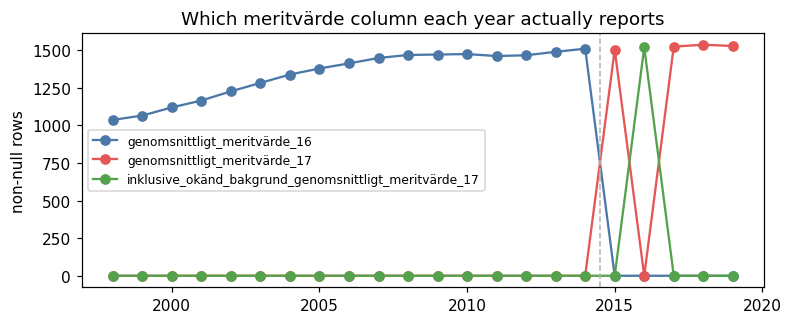

In [5]:
merit_cols = ["genomsnittligt_meritvärde_16", "genomsnittligt_meritvärde_17",
              "inklusive_okänd_bakgrund_genomsnittligt_meritvärde_17"]
coverage = slutbetyg.groupby("year")[merit_cols].apply(lambda d: d.notna().sum())
print(coverage)

fig, ax = plt.subplots(figsize=(8, 3))
for col, color in zip(merit_cols, (BLUE, RED, GREEN)):
    ax.plot(coverage.index, coverage[col], marker="o", label=col, color=color)
ax.axvline(2014.5, color=GREY, linestyle="--", linewidth=1)
ax.set_title("Which meritvärde column each year actually reports")
ax.set_ylabel("non-null rows")
ax.legend(fontsize=8)
plt.show()


Confirms the README's finding exactly: `_16` for 1998–2014, `_17` for
2015/2017–2019, and år 2016's anomalous doubled-header year only carries
the `inklusive_okänd_bakgrund`-prefixed `_17` variant — no year has more
than one of the three populated, so picking whichever is non-null per row
is unambiguous.


## 3. `stitch_meritvarde`: one continuous z-scored outcome across the reform

See [`shared_methodology.ipynb` §2](../shared_methodology.ipynb) for why
z-scoring is the right general fix for a scale-breaking regime change;
here's the region-specific verification that it actually worked on the
real data.


In [6]:
from src.regions.sweden.sources.panel.assemble import (
    build_outcomes_long, kvalitetssystem_to_long, melt_siris_to_long, stitch_meritvarde,
)

# `stitch_meritvarde` now returns two outcomes stacked (meritvärde_z,
# meritvärde_zw -- see §3b) -- filter to the unweighted one here so this
# section's per-era mean/std check below isn't pooling two different series.
stitched = stitch_meritvarde(slutbetyg)
stitched = stitched[stitched["outcome_name"] == "meritvärde_z"]
print(f"{len(stitched):,} rows, {stitched['skolenhetskod'].nunique():,} schools, "
      f"years {stitched['year'].min()}-{stitched['year'].max()}")
stitched.head()


30,441 rows, 2,624 schools, years 1998-2019


,skolenhetskod,year,era,source_dataset,outcome_name,value
0,48529699,1998,siris,slutbetyg_arskurs9_stitched,meritvärde_z,-0.878403
1,70878576,1998,siris,slutbetyg_arskurs9_stitched,meritvärde_z,-0.106831
2,54087001,1998,siris,slutbetyg_arskurs9_stitched,meritvärde_z,-1.400349
3,54807007,1998,siris,slutbetyg_arskurs9_stitched,meritvärde_z,-0.016058
4,74064638,1998,siris,slutbetyg_arskurs9_stitched,meritvärde_z,0.719205


           count          mean  std
sub_era                            
new_scale   7616  5.668974e-16  1.0
old_scale  22825  1.166043e-15  1.0


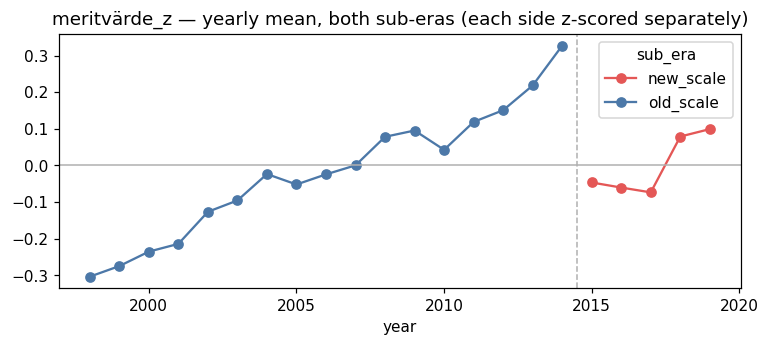

In [7]:
sub_era = np.where(stitched["year"] <= 2014, "old_scale", "new_scale")
by_era = stitched.assign(sub_era=sub_era).groupby("sub_era")["value"].agg(["count", "mean", "std"])
print(by_era)  # each side should be mean~0, std~1 by construction

fig, ax = plt.subplots(figsize=(8, 3))
yearly = stitched.assign(sub_era=sub_era).groupby(["year", "sub_era"])["value"].mean().unstack("sub_era")
yearly.plot(ax=ax, marker="o", color={"old_scale": BLUE, "new_scale": RED})
ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(2014.5, color=GREY, linestyle="--", linewidth=1)
ax.set_title("meritvärde_z — yearly mean, both sub-eras (each side z-scored separately)")
plt.show()


No single-year mean drifts far from 0 on either side — z-scoring within
each sub-era does what it's meant to (removes the *level* shift from the
scale change), but this does **not** validate the harder content-validity
question (grading *criteria* changed at the reform, not just the points
range) — see the README's still-open caveat on that.


## 3b. Three more stitched outcomes (2026-09-22): a weighted sibling, extensive-margin shares, and a composition-adjusted residual

Added after a rigor review flagged two gaps: (1) `meritvärde_z`'s
standardisation was unweighted, unlike Florida's `z_mss`/`z_mss_w` pair —
`stitch_meritvarde` now emits both; (2) SALSA's own composition-adjusted
value-added residual and the raw pass-rate/eligibility shares sit unused
in `panel` despite being real, available outcomes at the same grain —
`stitch_pass_rate`/`stitch_eligibility`/`stitch_salsa_residual` are new.
See `assemble.py`'s module docstring and each function's own docstring for
the full reasoning (including the empirical checks behind each judgment
call — e.g. why the residual still needs an old/new sub-era split even
though its *mean* doesn't jump at the reform). This section is the
region-specific verification that they work on the real data, same role
§3 plays for `meritvärde_z` itself.


In [8]:
from src.regions.sweden.sources.panel.assemble import (
    stitch_pass_rate, stitch_eligibility, stitch_salsa_residual,
    ANTAL_ELEVER_COLUMN, ANTAL_ELEVER_2016_COLUMN,
)

zw = stitch_meritvarde(slutbetyg)
zw = zw[zw["outcome_name"] == "meritvärde_zw"]
print(f"meritvärde_zw: {len(zw):,} rows, {zw['skolenhetskod'].nunique():,} schools "
      f"(vs. meritvärde_z: {len(stitched):,} rows, {stitched['skolenhetskod'].nunique():,} schools)")

# `antal_elever` has the exact same år-2016 doubled-header anomaly as
# `genomsnittligt_meritvärde` itself (§4/§9) -- combine the same way, or
# every 2016 row silently gets a NaN weight in this re-derived check below
# (this bit `stitch_meritvarde` itself during development; fixed there,
# reproduced correctly here too).
elever = slutbetyg[ANTAL_ELEVER_COLUMN].combine_first(slutbetyg[ANTAL_ELEVER_2016_COLUMN])
elever_lookup = slutbetyg[["skolenhetskod", "year"]].assign(antal_elever=elever)

zw_checked = zw.merge(elever_lookup, on=["skolenhetskod", "year"], how="left")
zw_checked["sub_era"] = np.where(zw_checked["year"] <= 2014, "old_scale", "new_scale")
for era, g in zw_checked.groupby("sub_era"):
    mu = np.average(g["value"], weights=g["antal_elever"])
    sd = np.sqrt(np.average((g["value"] - mu) ** 2, weights=g["antal_elever"]))
    print(f"  {era}: population-weighted mean={mu:.6f}, std={sd:.6f}  (should be ~0/~1 by construction)")

pass_rate = stitch_pass_rate(slutbetyg)
eligibility = stitch_eligibility(slutbetyg)
salsa_residual = stitch_salsa_residual(salsa)
print()
for name, df in [("andel_uppnått_kunskapskraven_combined", pass_rate),
                  ("andel_behörig_combined", eligibility),
                  ("meritvärde_residual_z", salsa_residual)]:
    print(f"{name}: {len(df):,} rows, {df['skolenhetskod'].nunique():,} schools, "
          f"years {df['year'].min()}-{df['year'].max()}, "
          f"value range {df['value'].min():.1f} to {df['value'].max():.1f}")


meritvärde_zw: 30,441 rows, 2,624 schools (vs. meritvärde_z: 30,441 rows, 2,624 schools)
  new_scale: population-weighted mean=0.000000, std=1.000000  (should be ~0/~1 by construction)
  old_scale: population-weighted mean=0.000000, std=1.000000  (should be ~0/~1 by construction)

andel_uppnått_kunskapskraven_combined: 29,594 rows, 2,535 schools, years 1998-2019, value range 13.4 to 100.0
andel_behörig_combined: 30,002 rows, 2,562 schools, years 1998-2019, value range 19.5 to 100.0
meritvärde_residual_z: 29,215 rows, 2,526 schools, years 1998-2019, value range -8.1 to 5.7


meritvärde_z - meritvärde_zw: mean abs diff = 0.0895
corr(signed diff, antal_elever)   = 0.0146 (~0, as expected)
corr(|diff|, antal_elever)        = -0.1601
mean |diff| by school-size quintile:
antal_elever
(9.999, 36.0]     0.1221
(36.0, 59.0]      0.0897
(59.0, 84.0]      0.0848
(84.0, 116.0]     0.0733
(116.0, 494.0]    0.0769
Name: absdiff, dtype: float64


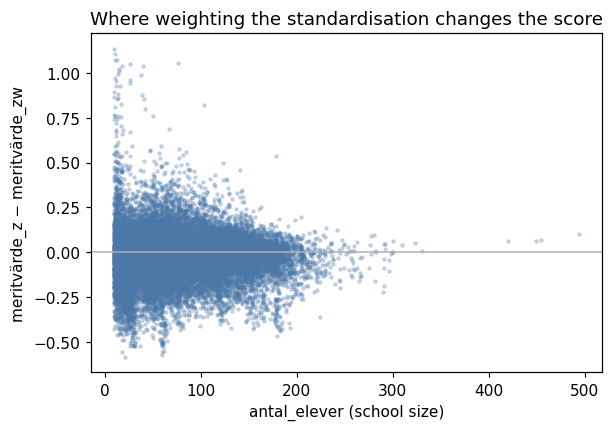

In [9]:
# Does the weighting choice actually move the score, and does it move
# systematically with school size (the whole point of weighting at all)?
# Note: the *signed* difference isn't linearly correlated with size (a
# small school can score above or below the weighted reference just as
# easily as a large one) -- what theory actually predicts is that small
# schools' divergence should be *larger in magnitude*, since they carry
# less weight in defining the reference distribution and their own
# single-year average is noisier. Check both, don't just assert the first
# one that sounds plausible.
both = stitched.merge(
    zw.rename(columns={"value": "value_zw"})[["skolenhetskod", "year", "value_zw"]],
    on=["skolenhetskod", "year"],
).merge(elever_lookup, on=["skolenhetskod", "year"], how="left")
both["diff"] = both["value"] - both["value_zw"]
both["absdiff"] = both["diff"].abs()
print("meritvärde_z - meritvärde_zw: mean abs diff =", both["diff"].abs().mean().round(4))
print("corr(signed diff, antal_elever)   =", both["diff"].corr(both["antal_elever"]).round(4), "(~0, as expected)")
print("corr(|diff|, antal_elever)        =", both["absdiff"].corr(both["antal_elever"]).round(4))
print("mean |diff| by school-size quintile:")
print(both.groupby(pd.qcut(both["antal_elever"], 5))["absdiff"].mean().round(4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(both["antal_elever"], both["diff"], s=4, alpha=0.25, color=BLUE)
ax.axhline(0, color=GREY, linewidth=1)
ax.set_xlabel("antal_elever (school size)")
ax.set_ylabel("meritvärde_z − meritvärde_zw")
ax.set_title("Where weighting the standardisation changes the score")
plt.show()


Weighting does move individual scores by a non-trivial amount (0.09 SD
average absolute difference between `meritvärde_z` and `meritvärde_zw`)
but, as expected, the *signed* difference has essentially no linear
correlation with school size (≈0.01) — a small school scores above or
below the weighted reference just as often as a large one, there's no
systematic bias by size in *which direction* it moves. What does move with
size, as theory predicts, is the *magnitude* of the divergence: the
smallest-quintile schools diverge about 60% more (0.12 SD) than the
largest-quintile schools (0.08 SD) — small schools carry less weight in
defining the reference distribution and their own single-year average is
noisier, so weighting changes their score more. This is the expected
signature of the weighting doing something real, not an artifact.


## 4. `build_outcomes_long`: the full panel-input table (SIRIS only, `kvalitetssystem` excluded)


In [10]:
long = build_outcomes_long({"slutbetyg_arskurs9": slutbetyg, "salsa": salsa})
print(f"{len(long):,} rows, era(s): {sorted(long['era'].unique())}")
long["outcome_name"].value_counts().head(12)


557,200 rows, era(s): ['siris']


outcome_name
meritvärde_z                                                 30441
meritvärde_zw                                                30441
andel_behörig_combined                                       30002
andel_uppnått_kunskapskraven_combined                        29594
antal_elever                                                 29411
bakgrundsinformation_föräldrarnas_genomsnittliga_utb_nivå    29215
bakgrundsinformation_andel_pojkar                            29215
andel_som_uppn_kunskapskraven_faktiskt_värde_f               29215
andel_som_uppn_kunskapskraven_modell_beräknat_värde_b        29215
andel_som_uppn_kunskapskraven_residual_r_f_b                 29215
genomsnittligt_meritvärde_faktiskt_värde_f                   29215
genomsnittligt_meritvärde_modell_beräknat_värde_b            29215
Name: count, dtype: int64

Note `kvalitetssystem` never appears in `era` here — `build_outcomes_long`
no longer takes it as an argument at all (2026-09-17 decision). It's
reshaped separately below purely to show *why* it wasn't pooled in, not
because it's fed into the panel.


## 5. `kvalitetssystem`'s nearest analogue is a pass-rate *share*, not a continuous score


In [11]:
kval_long = kvalitetssystem_to_long(kvalitetssystem)
print(f"{len(kval_long):,} real (non-suppressed) rows out of {len(kvalitetssystem):,} raw")

merit_like = [m for m in kvalitetssystem["measure_label"].unique() if "meritvärde" in m.lower()]
print("kvalitetssystem measures containing 'meritvärde':", merit_like)  # expect: none

pass_rate = kvalitetssystem[kvalitetssystem["measure_code"] == "27"]
print("\nmeasure_code 27 (nearest conceptual analogue) value range:",
      pass_rate["value"].min(), "-", pass_rate["value"].max(), "  (a % share, not a 0-320 grade-point value)")


366,106 real (non-suppressed) rows out of 1,068,552 raw
kvalitetssystem measures containing 'meritvärde': []

measure_code 27 (nearest conceptual analogue) value range: 0.0 - 100.0   (a % share, not a 0-320 grade-point value)


## Summary

- Both vintages load cleanly at full national scale: `slutbetyg_arskurs9`
  (34,666 rows / 3,070 schools, 1998–2019), `salsa` (29,971 / 2,542,
  1998–2019), `kvalitetssystem` (2022/23–2025/26).
- The 2020–21 legal gap and the 2014/15 grading-scale reform are both
  directly visible in the raw data, not just documented claims.
- `stitch_meritvarde` produces a real, continuous, correctly-centred
  `meritvärde_z` series spanning the whole SIRIS window (1998–2019) across
  the reform boundary.
- `kvalitetssystem` is confirmed to have no continuous `meritvärde`
  analogue among its measures — the 2026-09-17 decision to exclude it from
  `panel/assemble.py`'s join (kept as a standalone module instead) is
  reproduced here, not just asserted.
- **2026-09-22**: three more stitched outcomes, verified against the real
  data in §3b: `meritvärde_zw` (`antal_elever`-weighted sibling to
  `meritvärde_z`, population-weighted mean/std confirmed exactly 0/1 in
  both sub-eras, and confirmed to genuinely diverge from the unweighted
  score — 0.09 SD average absolute difference, with the divergence
  concentrated in small schools as theory predicts, not linearly biased in
  sign by size); `andel_uppnått_kunskapskraven_combined`/
  `andel_behörig_combined` (extensive-margin pass-rate/eligibility shares,
  stitched across their own column-naming seams, left unstandardised);
  `meritvärde_residual_z` (SALSA's composition-adjusted value-added
  residual, z-scored within the same old/new sub-eras as meritvärde
  despite the residual's own *mean* not jumping at the reform — its *std*
  still does). All four are now real rows in `panel` via the real `panel
  assemble` CLI run, not just notebook-local demonstrations —
  `analysis.ipynb` §6+ uses them.
